In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_excel('rawdata.xls',header=1)

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [23]:
print(df.shape)

(30000, 27)


So,there are 30K records with 27 features.

In [6]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

- No NULL value found in any of the records

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [25]:
print("The number of duplicate Entries : ",df.duplicated().sum())

The number of duplicate Entries :  0


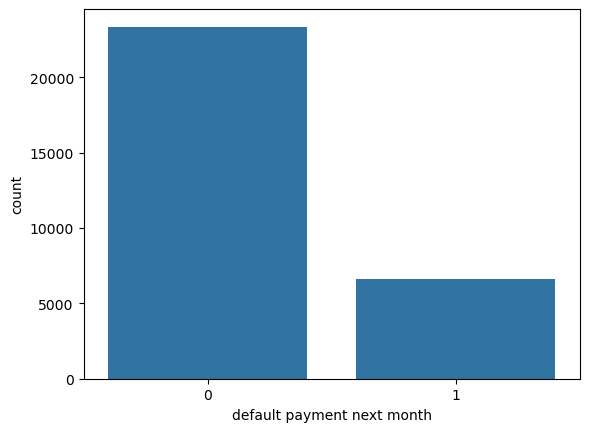

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='default payment next month', data=df)
plt.show()

-  From the bove plot we can see that the data is highly imbalanced.
-  We SMOTE(Synthetic Minority OverSampling Technique) to tackle the imbalanced 
 dataset

### Numerical Feature Analysis

In [16]:
bill_cols = [
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6'
]

mean_bills = df.groupby(
    'default payment next month'
)[bill_cols].mean().T

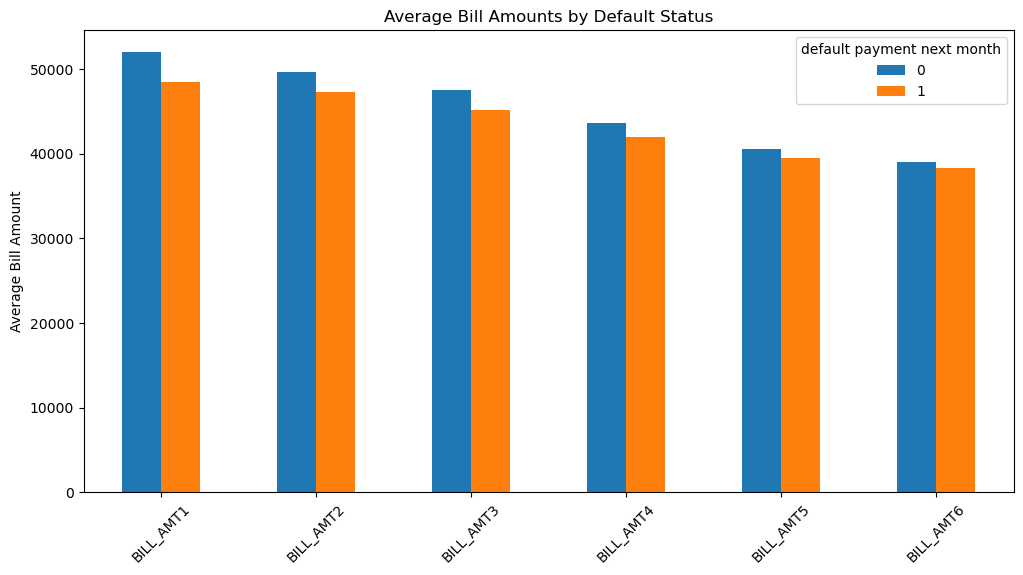

In [17]:
mean_bills.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Average Bill Amounts by Default Status')

plt.ylabel('Average Bill Amount')

plt.xticks(rotation=45)

plt.show()

- Defaulters consistently maintain higher outstanding bill amounts across multiple months.

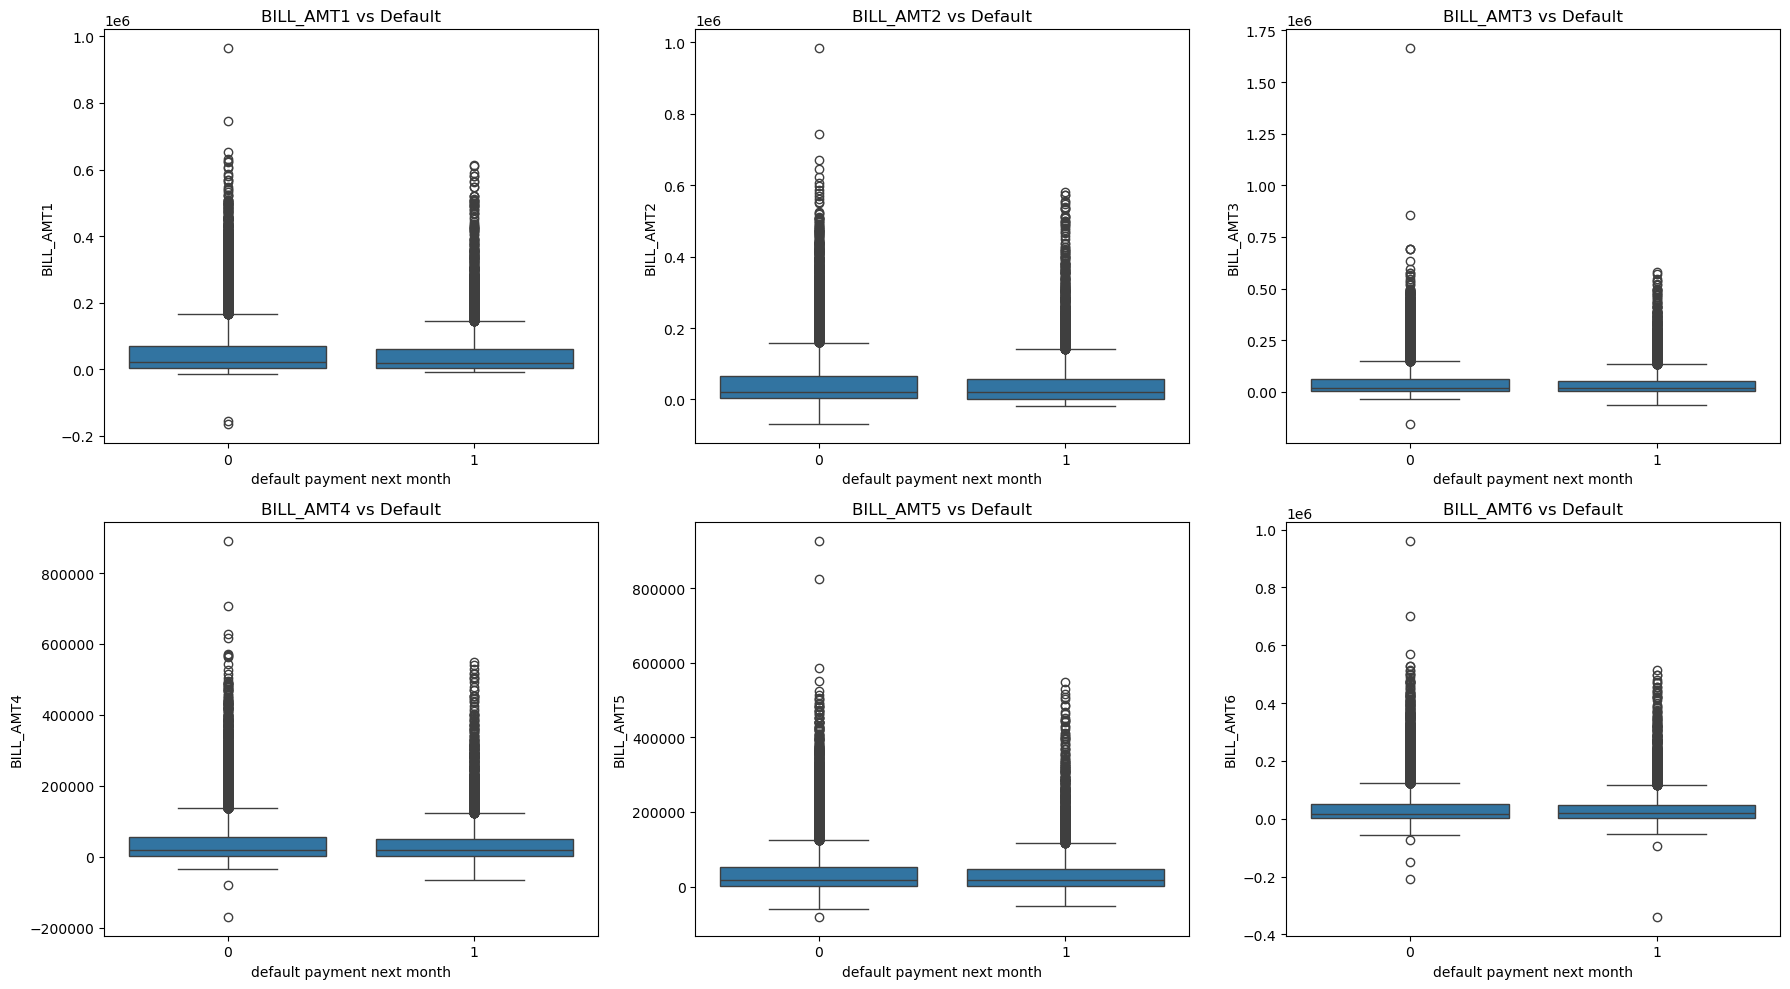

In [19]:
bill_cols = [
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6'
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for i, col in enumerate(bill_cols):
    
    sns.boxplot(
        x='default payment next month',
        y=col,
        data=df,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} vs Default')

plt.tight_layout()

plt.show()

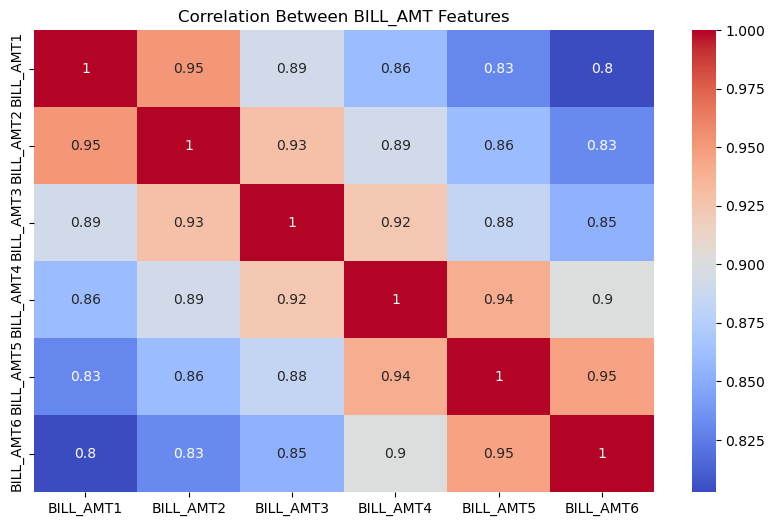

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[bill_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between BILL_AMT Features')

plt.show()

- BILL_AMT variables exhibit strong positive correlation, indicating persistence in customer billing behavior across consecutive months.

<Axes: xlabel='AGE_BIN', ylabel='count'>

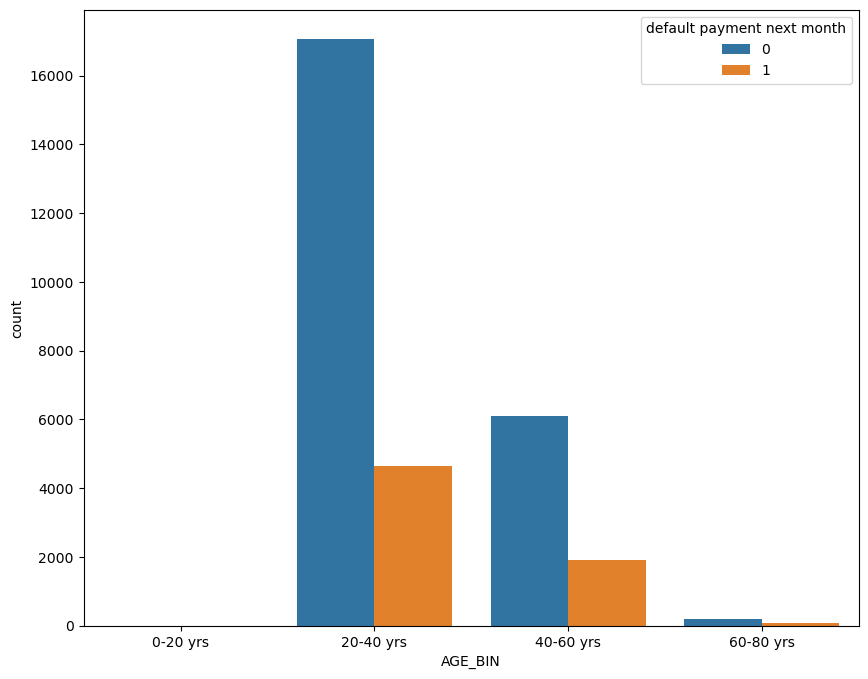

In [11]:
df['AGE_BIN'] = pd.cut(
    df['AGE'],
    bins=[0, 20, 40, 60, 80],
    labels=['0-20 yrs', '20-40 yrs', '40-60 yrs', '60-80 yrs']
)

plt.figure(figsize=(10,8))
sns.countplot(x="AGE_BIN",hue="default payment next month",data=df)

- Customers from lower age group has more number of defaulters.

C:\Users\PRIYAM KUMAR DE\AppData\Local\Temp\ipykernel_20564\1262485412.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df.groupby('LIMIT_BAL_BIN')['default payment next month'].mean() * 100


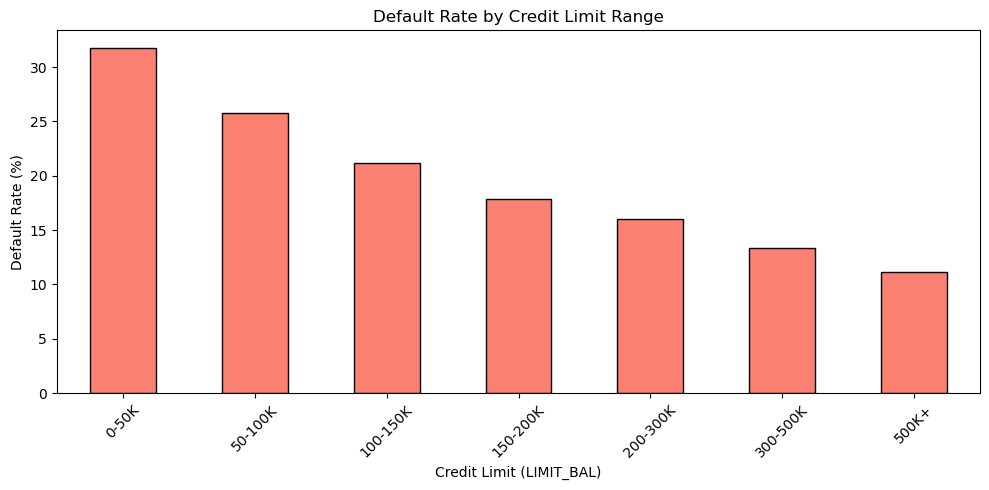

In [12]:


# Bin LIMIT_BAL into meaningful ranges
df['LIMIT_BAL_BIN'] = pd.cut(
    df['LIMIT_BAL'],
    bins=[0, 50000, 100000, 150000, 200000, 300000, 500000, 1000000],
    labels=['0-50K', '50-100K', '100-150K', '150-200K', '200-300K', '300-500K', '500K+']
)

# Calculate default RATE per bin (not count)
default_rate = df.groupby('LIMIT_BAL_BIN')['default payment next month'].mean() * 100

# Plot
plt.figure(figsize=(10, 5))
default_rate.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Default Rate by Credit Limit Range')
plt.xlabel('Credit Limit (LIMIT_BAL)')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Customers with lower credit limits (LIMIT_BAL < 50K) default at a significantly higher rate compared to those with higher limits, suggesting credit limit is inversely correlated with default risk

### Categorical Feature Analysis

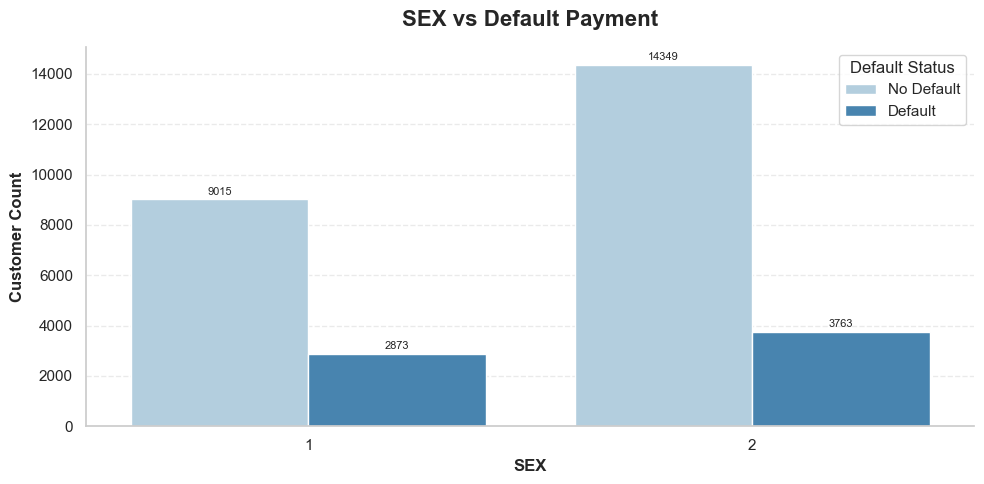

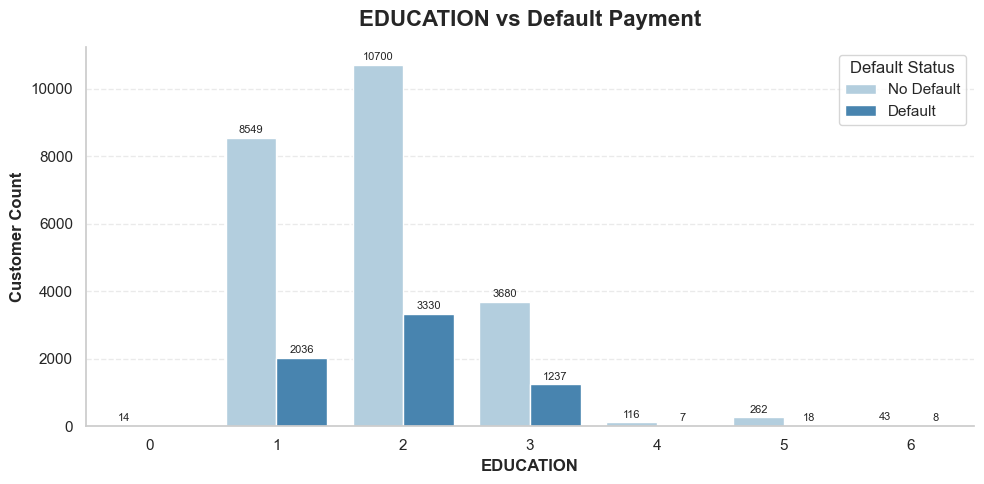

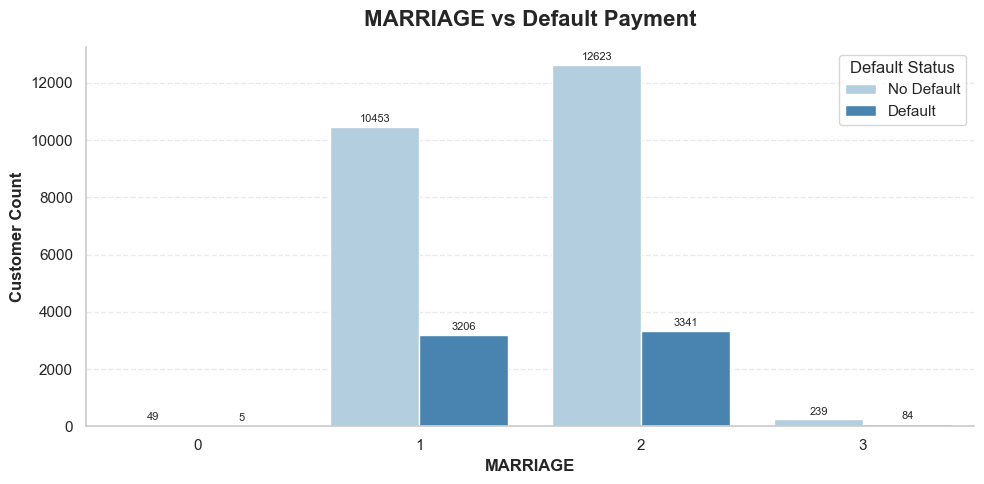

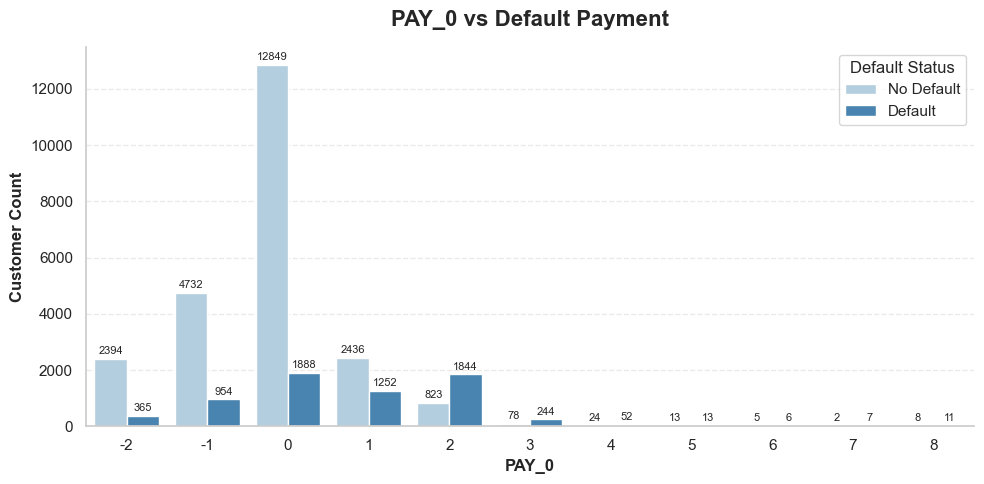

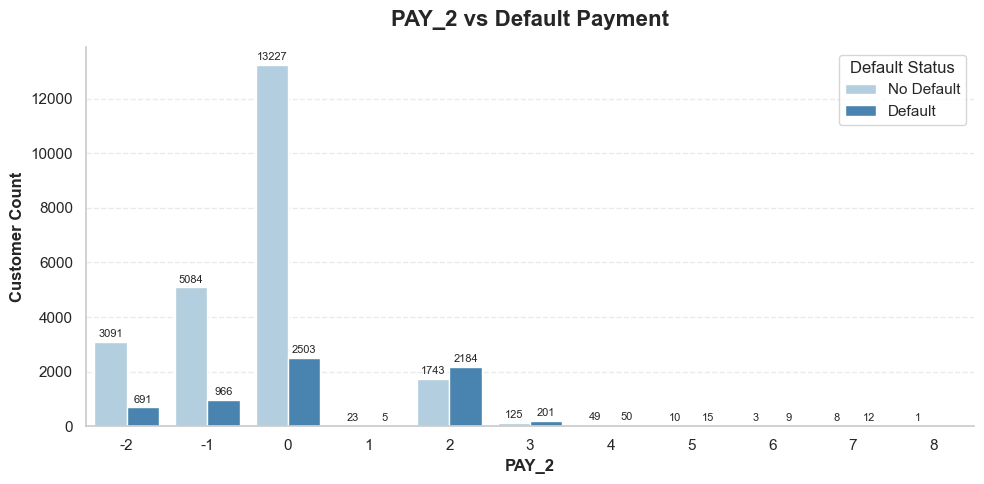

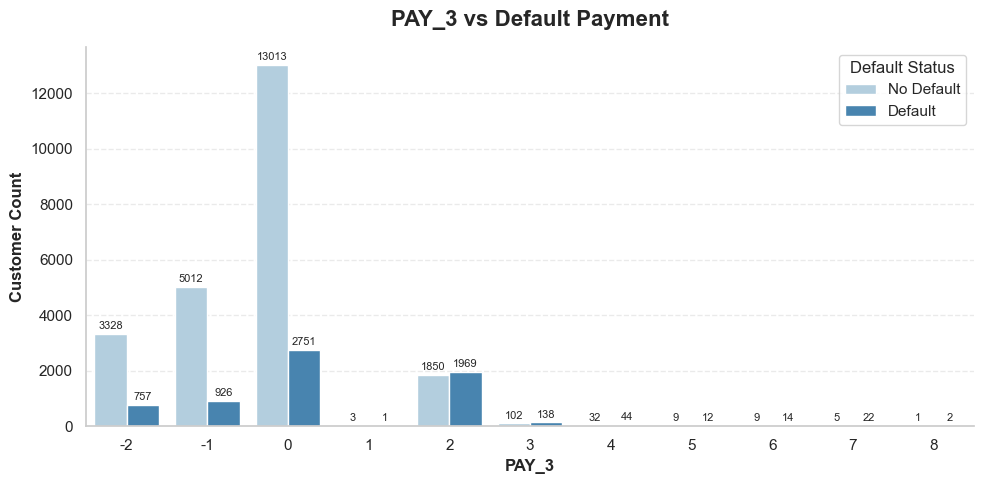

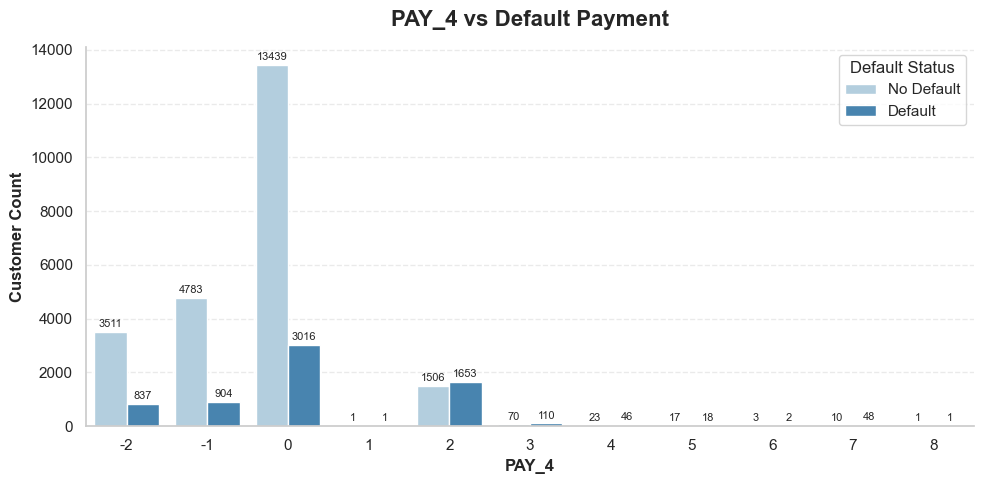

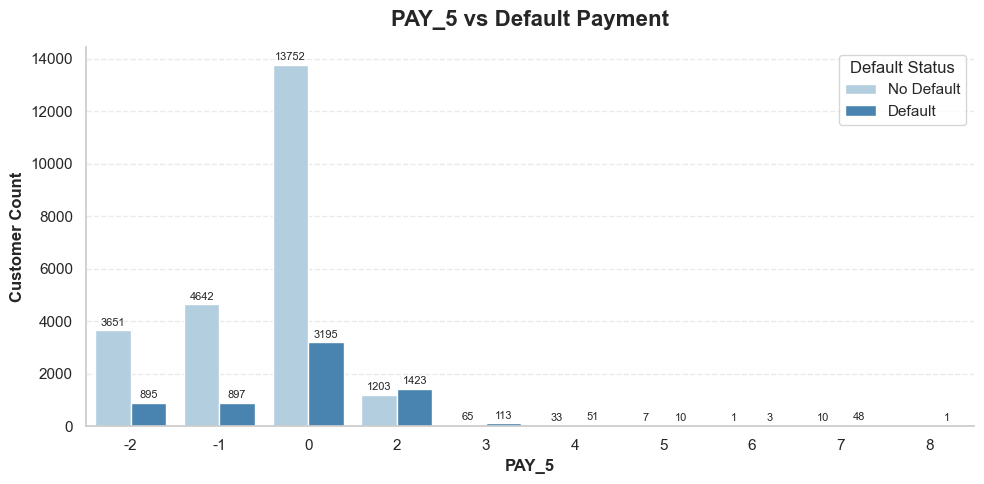

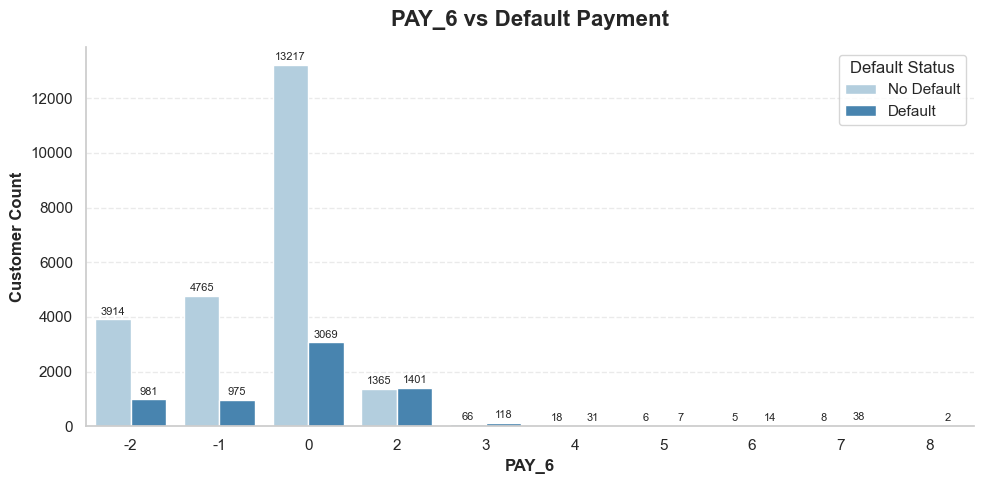

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global styling
sns.set_theme(
    style="whitegrid",
    palette="crest"
)

categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

for col in categorical_cols:
    
    plt.figure(figsize=(10,5))
    
    ax = sns.countplot(
        x=col,
        hue='default payment next month',
        data=df,
        palette='Blues'
    )
    
    # Title Styling
    plt.title(
        f'{col} vs Default Payment',
        fontsize=16,
        fontweight='bold',
        pad=15
    )
    
    # Axis Labels
    plt.xlabel(
        col,
        fontsize=12,
        fontweight='semibold'
    )
    
    plt.ylabel(
        'Customer Count',
        fontsize=12,
        fontweight='semibold'
    )
    
    # Grid Styling
    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )
    
    # Legend Styling
    plt.legend(
        title='Default Status',
        labels=['No Default', 'Default'],
        frameon=True
    )
    
    # Remove top/right borders
    sns.despine()
    
    # Add count labels on bars
    for container in ax.containers:
        ax.bar_label(
            container,
            padding=2,
            fontsize=8
        )
    
    plt.tight_layout()
    
    plt.show()


(From the above analysis categorical features with the deafult payment in next month)

- Gender does not show a significant impact on default payment behavior.
- Customers with lower education levels tend to exhibit higher default rates.
- Younger customers appear to have a higher tendency to default compared to    older customers.
- Repayment status features (PAY_0 to PAY_6) show a strong relationship with default probability, where increasing payment delays correspond to higher chances of default.
- Customers with a history of delayed payments are more likely to become defaulters in the following month.

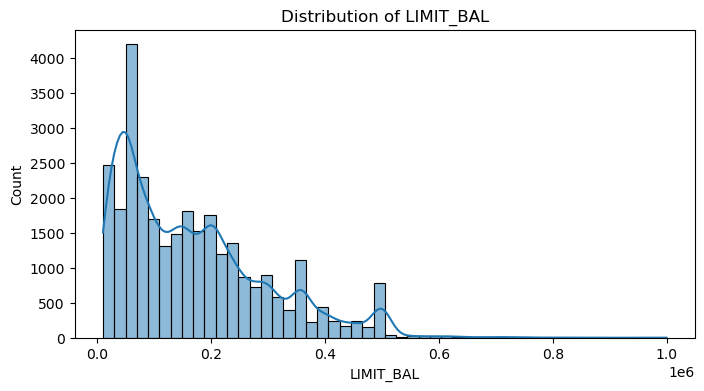

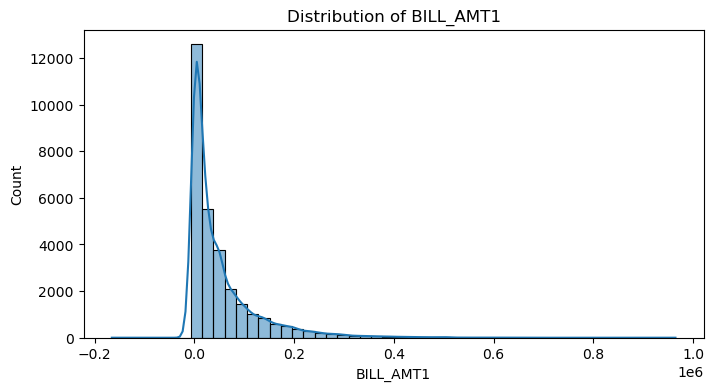

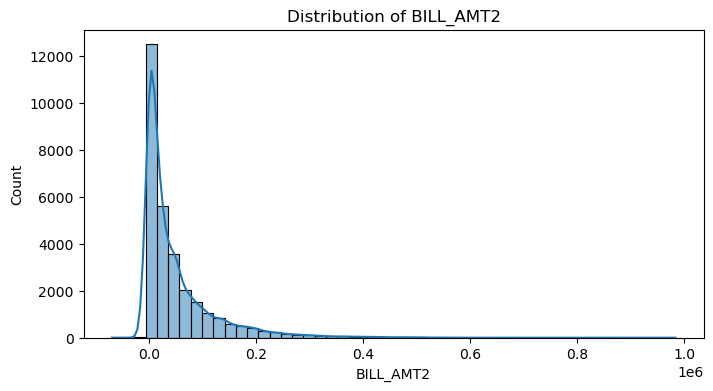

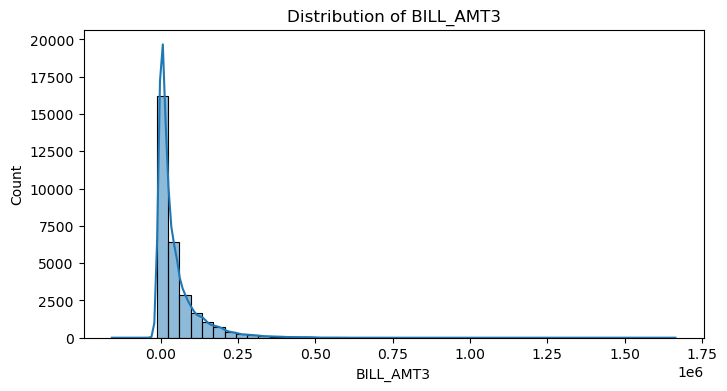

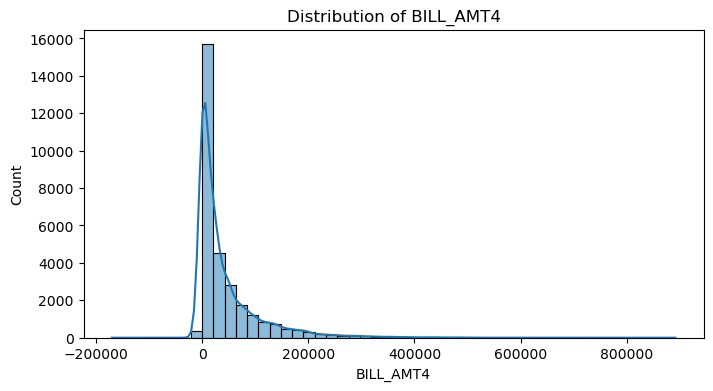

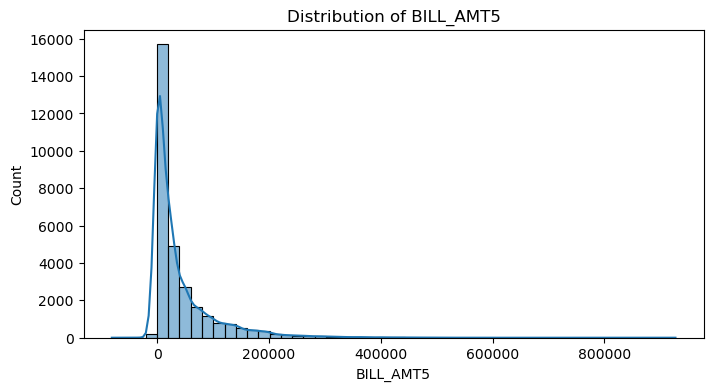

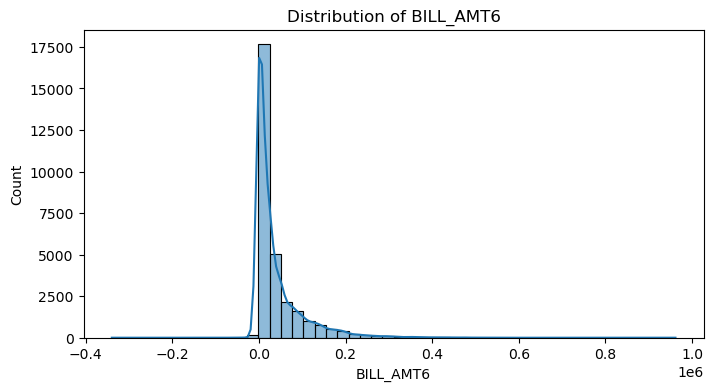

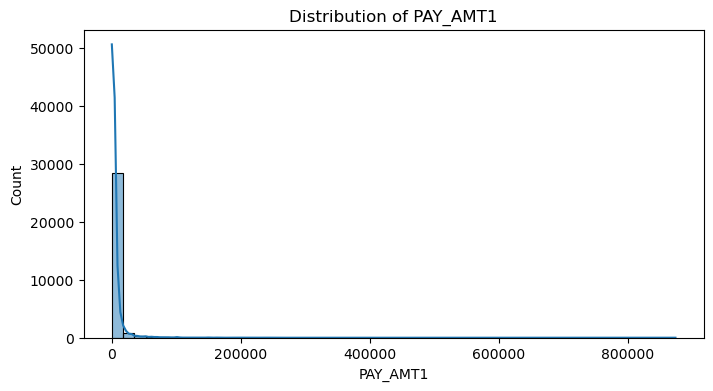

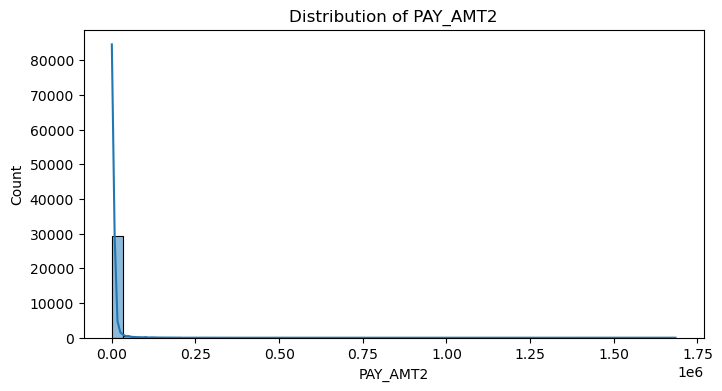

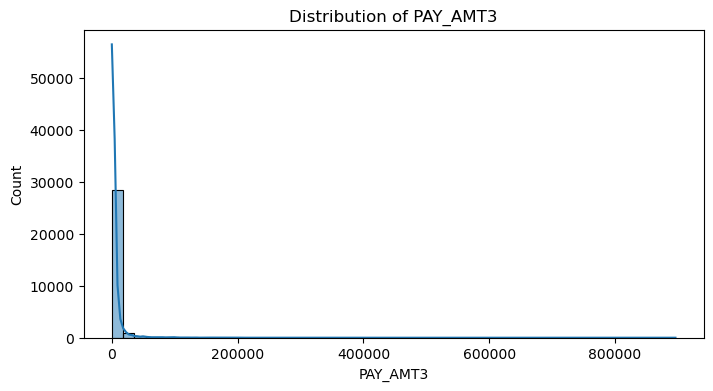

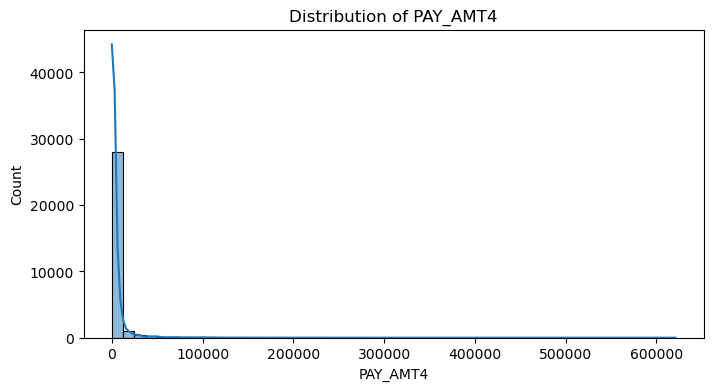

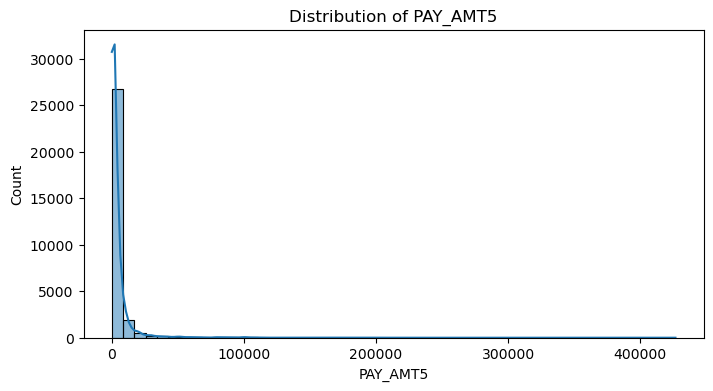

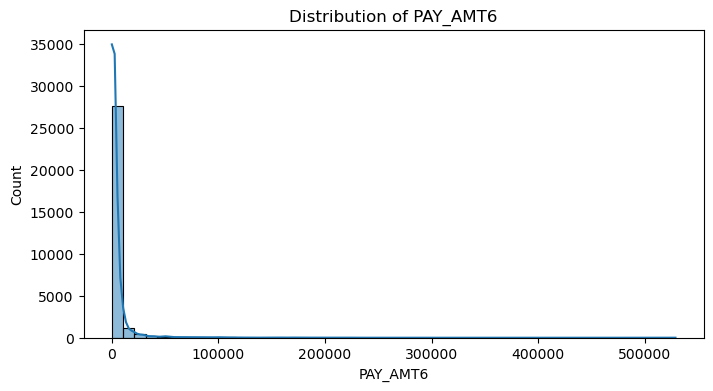

In [28]:
financial_cols = [
    'LIMIT_BAL',
    'BILL_AMT1',
    'BILL_AMT2',
    'BILL_AMT3',
    'BILL_AMT4',
    'BILL_AMT5',
    'BILL_AMT6',
    'PAY_AMT1',
    'PAY_AMT2',
    'PAY_AMT3',
    'PAY_AMT4',
    'PAY_AMT5',
    'PAY_AMT6'
]
import matplotlib.pyplot as plt
import seaborn as sns

for col in financial_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        df[col],
        bins=50,
        kde=True
    )
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

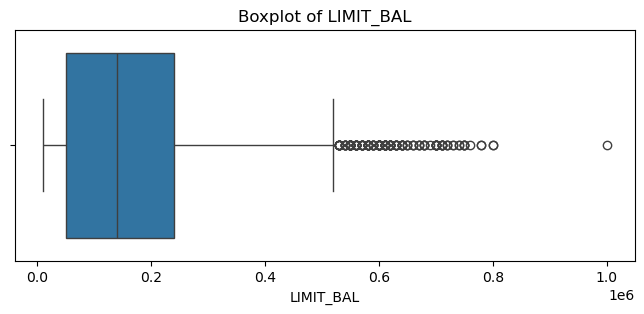

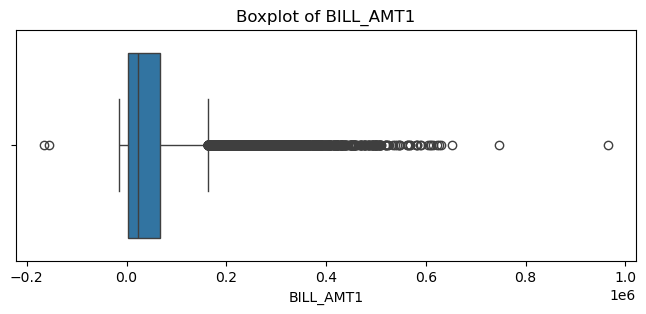

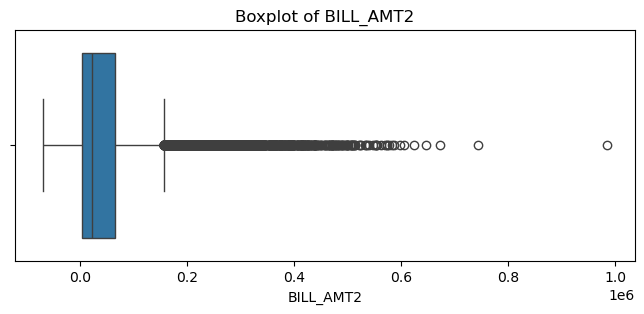

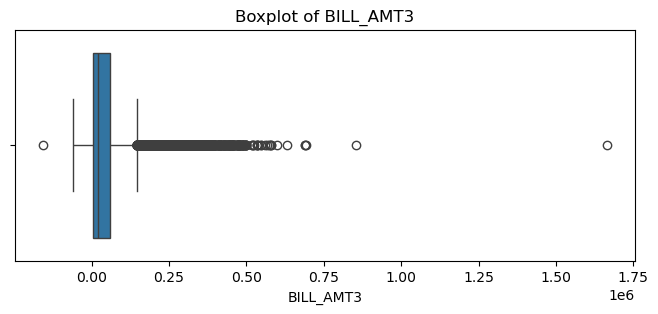

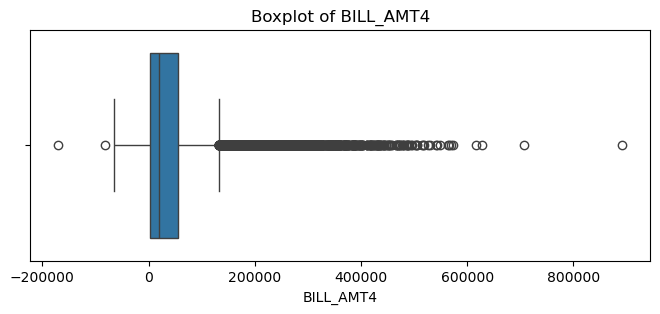

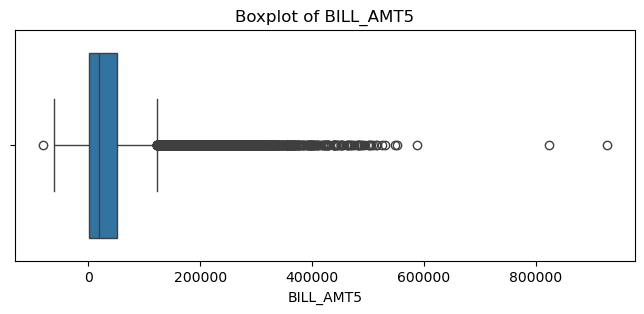

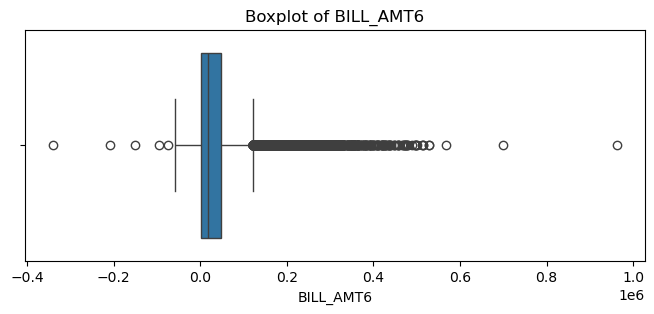

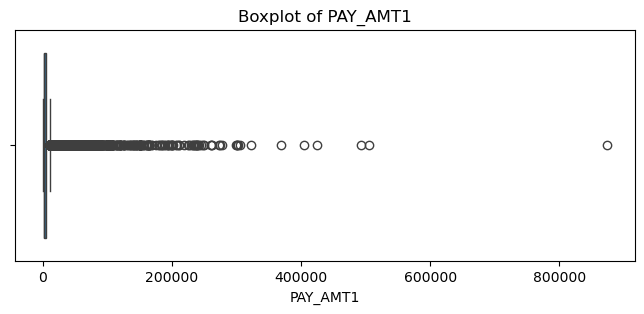

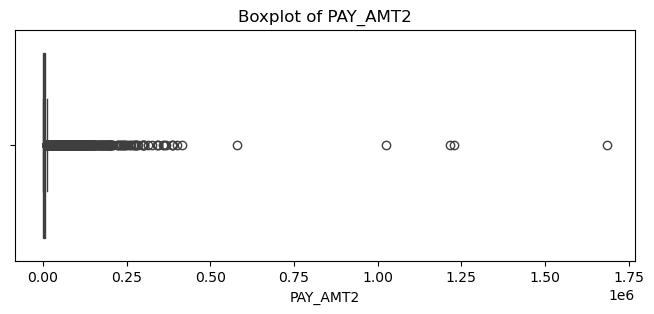

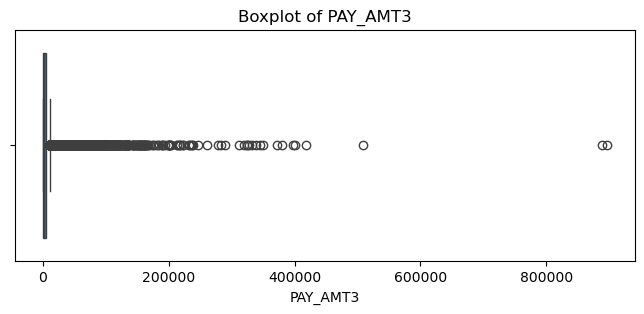

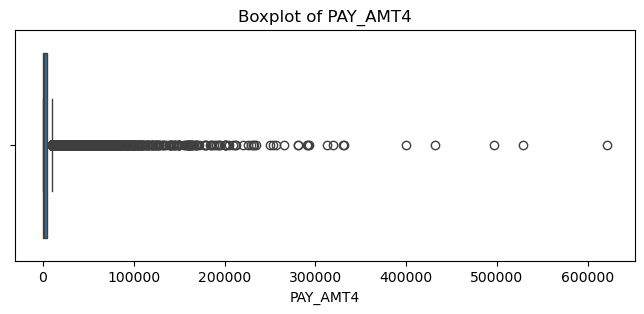

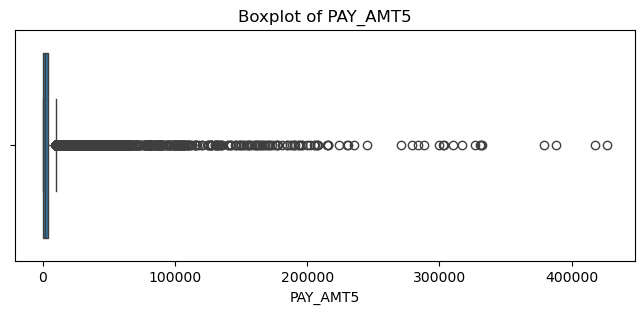

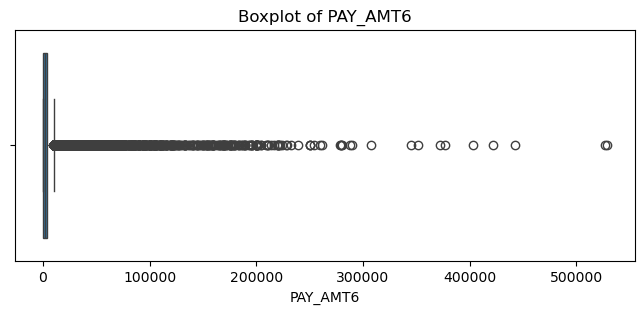

In [29]:
for col in financial_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

Financial variables exhibit highly right-skewed distributions with several extreme outliers, indicating significant variation in customer financial behavior.

## CONCLUSIONS

1. The dataset is moderately imbalanced, with non-default cases significantly outnumbering default cases.
2. Repayment history features (PAY_0 to PAY_6) exhibit a strong relationship with default payment behavior, where increasing payment delays correspond to higher default probability.
3. Customers with lower credit limits tend to show a higher likelihood of default.
4. Younger customers demonstrate relatively higher default tendencies compared to older customers.
5. BILL_AMT features show strong positive correlation across consecutive months, indicating persistent billing behavior    over time.
6. Customers with consistently high outstanding bill amounts are more likely to default.
7. Financial variables contain substantial outliers and right-skewed distributions.
8. Several billing and payment-related variables are highly correlated, suggesting potential multicollinearity among financial features.
9. Feature scaling and imbalance handling techniques such as SMOTE may help improve model performance during the modeling phase.